# Local YOLOv8-Seg Training on NVIDIA RTX 4050 (6GB VRAM)

This notebook is specifically configured for **local execution** on your **NVIDIA GeForce RTX 4050 (6GB Laptop GPU)**.

### **Hardware Optimization Highlights**
- **Batch Size**: `batch=8` (optimal sweet spot for 6GB VRAM, preventing CUDA OOM while saturating Tensor Cores).
- **Mixed Precision (AMP)**: Uses Ada Lovelace 4th Gen Tensor Cores for 2x faster FP16 training.
- **Workers**: `workers=4` for parallel CPU data prefetching from your local NVMe SSD.
- **Memory Allocator**: Configures PyTorch expandable segments to prevent VRAM fragmentation.
- **Checkpoints**: Automatically saves `best.pt` and `last.pt` locally after every epoch.

## Step 1: Verify RTX 4050 Hardware & CUDA Setup

In [ ]:
import os
import torch
import ultralytics

# Optimize CUDA VRAM allocation for 6GB
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cudnn.benchmark = True

print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version:     {torch.__version__}")
print(f"CUDA Available:      {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Detected:        {gpu_name}")
    print(f"Total VRAM:          {total_vram:.2f} GB")
    print("\nCUDA GPU acceleration is active and ready for RTX 4050!")
else:
    print("\nCUDA not active. Please install PyTorch with CUDA 12.1 matching your NVIDIA driver:")
    print("pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121")


## Step 2: Locate Local Dataset & Generate `data.yaml`
Searches for `dataset_5000` on your local SSD and configures local training paths.

In [ ]:
from pathlib import Path
import zipfile

# Search common local dataset locations
possible_paths = [
    Path("/home/utkarsh/Desktop/floorPlanGenerator/dataset_5000"),
    Path("/home/utkarsh/Desktop/floorPlanReader/data/dataset_5000"),
    Path.cwd() / "data" / "dataset_5000",
    Path.cwd().parent / "data" / "dataset_5000",
]

dataset_dir = next((p for p in possible_paths if p.exists()), None)

# If only zip exists, unzip locally
if not dataset_dir:
    zip_candidates = [
        Path("/home/utkarsh/Desktop/floorPlanGenerator/dataset_5000.zip"),
        Path.cwd() / "data" / "dataset_5000.zip",
        Path.cwd().parent / "data" / "dataset_5000.zip",
    ]
    zip_file = next((z for z in zip_candidates if z.exists()), None)
    if zip_file:
        extract_dest = Path.cwd() / "data" / "dataset_5000"
        print(f"Extracting {zip_file} to {extract_dest}...")
        with zipfile.ZipFile(zip_file, 'r') as z:
            z.extractall(extract_dest)
        dataset_dir = extract_dest

if not dataset_dir or not dataset_dir.exists():
    raise FileNotFoundError("Could not find dataset_5000 directory or zip on local drive!")

print(f"Found Dataset: {dataset_dir}")

# Configure local data.yaml pointing to valid local files
yaml_path = dataset_dir / "data.yaml"
train_path = dataset_dir / "images" / "train"
val_path = dataset_dir / "images" / "val"

CLASSES = [
    "bedroom", "living_room", "kitchen", "bathroom", "hallway",
    "balcony", "room", "door", "window", "wall"
]

yaml_content = f"""path: {dataset_dir.resolve()}
train: {train_path.resolve()}
val: {val_path.resolve()}

names:
"""
for i, c in enumerate(CLASSES):
    yaml_content += f"  {i}: {c}\n"

yaml_path.write_text(yaml_content)
print(f"Updated {yaml_path} with verified local absolute paths.")


## Step 3: Train YOLOv8-Seg on Local RTX 4050
Trains with `batch=8`, `amp=True`, and local checkpointing to `weights/rtx4050_best.pt`.

In [ ]:
import shutil
from pathlib import Path
from ultralytics import YOLO
import torch

# Output directory for trained weights
output_weights_dir = Path.cwd() / "weights"
output_weights_dir.mkdir(parents=True, exist_ok=True)

# Resume from existing checkpoint if available, otherwise start from yolov8s-seg.pt
resume_file = output_weights_dir / "rtx4050_last.pt"
can_resume = resume_file.exists()

if can_resume:
    print(f"Resuming training from local checkpoint: {resume_file}")
    model = YOLO(str(resume_file))
else:
    print("Starting fresh training with yolov8s-seg.pt...")
    model = YOLO("yolov8s-seg.pt")

# Callback to preserve best.pt and last.pt after EVERY epoch
def on_fit_epoch_end_callback(trainer):
    ep = trainer.epoch + 1
    tot = trainer.epochs
    if trainer.best.exists():
        shutil.copy2(trainer.best, output_weights_dir / "rtx4050_best.pt")
    if trainer.last.exists():
        shutil.copy2(trainer.last, output_weights_dir / "rtx4050_last.pt")
    print(f"\n[Epoch {ep}/{tot}] Saved local weights to: {output_weights_dir / 'rtx4050_best.pt'}")

model.add_callback("on_fit_epoch_end", on_fit_epoch_end_callback)

# RTX 4050 Hyperparameters
EPOCHS = 50
BATCH_SIZE = 8       # Ideal for 6GB VRAM (no OOM, maximum Tensor Core saturation)
IMGSZ = 640
WORKERS = 4          # Parallel CPU batch loader

print(f"Training config: Device=RTX 4050, Batch={BATCH_SIZE}, Imgsz={IMGSZ}, Epochs={EPOCHS}")

if can_resume:
    results = model.train(resume=True)
else:
    results = model.train(
        data=str(yaml_path),
        epochs=EPOCHS,
        batch=BATCH_SIZE,
        imgsz=IMGSZ,
        device=0 if torch.cuda.is_available() else "cpu",
        workers=WORKERS,
        amp=True,
        retina_masks=True,
        save=True,
        verbose=True
    )


## Step 4: Select / Upload Any Blueprint & Run Inference
Opens a file browser or prompt to select **any** floor plan image on your computer, detects all rooms, dimensions, windows, and doors.

✅ Loading Trained Model: /home/utkarsh/Desktop/floorPlanReader/notebooks/weights/rtx4050_best.pt
📁 Analyzing Blueprint: /home/utkarsh/Downloads/floorPlanTestOnline.png

🏠 DETECTED ARCHITECTURAL ELEMENTS:
  • Rooms:   11
  • Windows: 28
  • Doors:   29
  • Walls:   50

#   | Room Type          | Confidence | Dimensions (L x W) | Area
----------------------------------------------------------------------
1   | Bathroom           | 0.94       | 5.86m x 1.93m      | 11.31 m²
2   | Bathroom           | 0.85       | 3.43m x 2.83m      | 9.71 m²
3   | Bathroom           | 0.32       | 5.52m x 4.67m      | 25.78 m²
4   | Bedroom            | 0.31       | 3.18m x 0.38m      | 1.21 m²
5   | Living Room        | 0.30       | 3.05m x 3.03m      | 9.24 m²
6   | Bathroom           | 0.29       | 5.70m x 1.96m      | 11.17 m²
7   | Bedroom            | 0.27       | 3.45m x 2.98m      | 10.28 m²
8   | Bathroom           | 0.26       | 3.73m x 3.00m      | 11.19 m²
9   | Room               | 0.24      

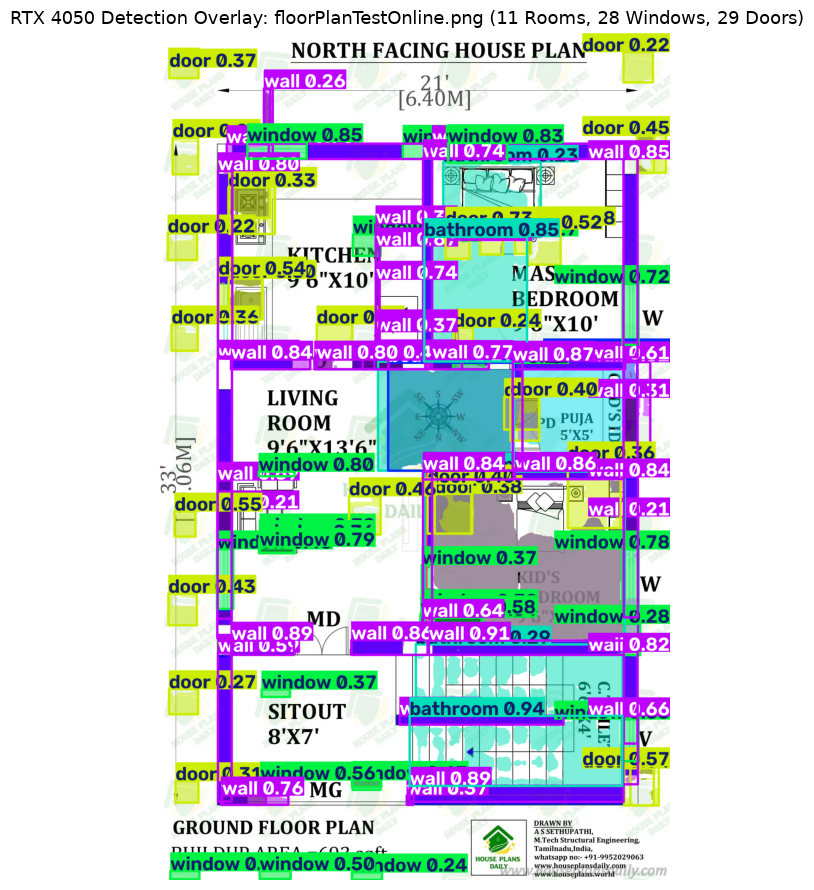

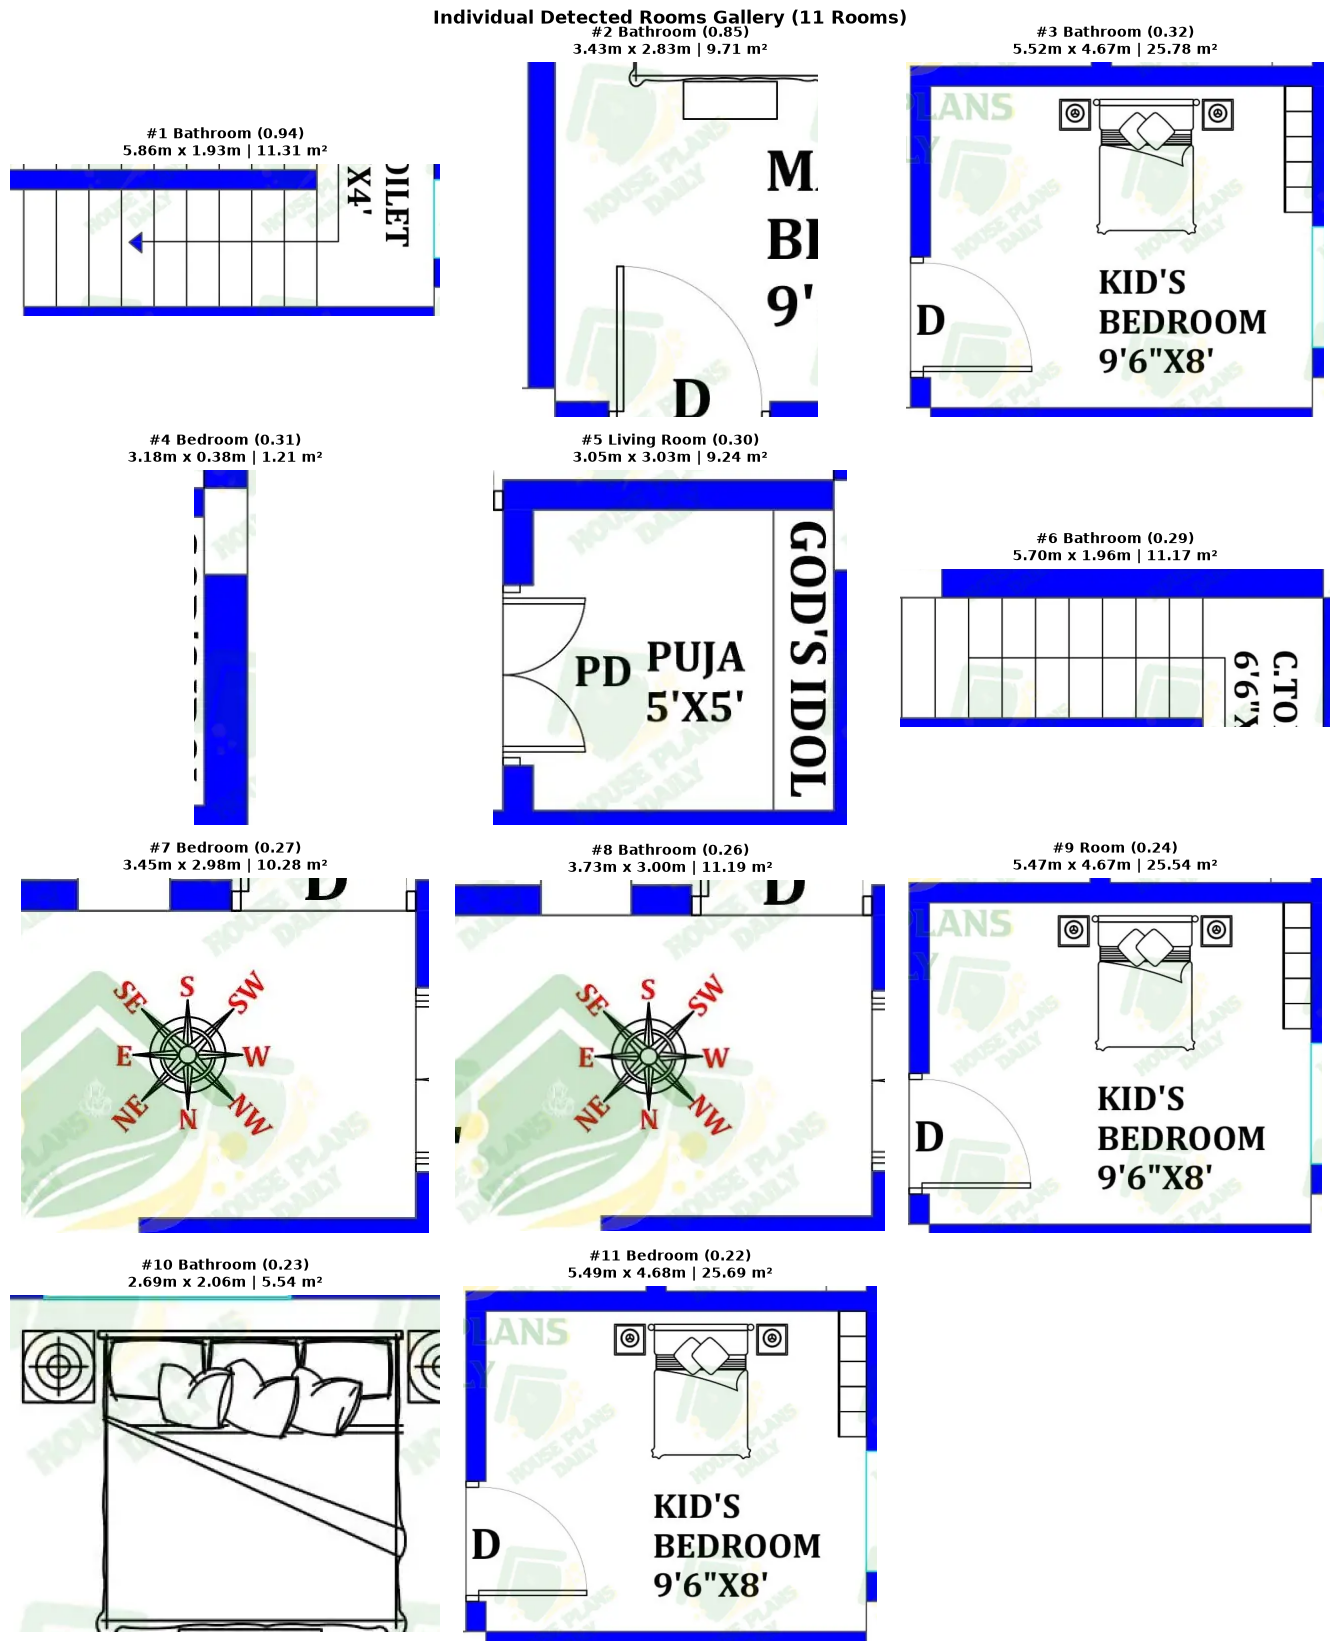

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import torch

# ==============================================================================
# 👇 1. TYPE OR PASTE ANY IMAGE PATH HERE (or drag & drop file into folder):
# ==============================================================================
IMAGE_PATH = "/home/utkarsh/Downloads/studio-apartment-2d.png" 

# Examples you can test:
# IMAGE_PATH = "blueprint.png"
# IMAGE_PATH = "/home/utkarsh/Downloads/executive-office-suite-2d.png"
# IMAGE_PATH = "data/test_samples/sample_1bhk.png"

# ==============================================================================
# 2. RESOLVE TRAINED WEIGHTS & BLUEPRINT
# ==============================================================================
weights_candidates = [
    Path.cwd() / "weights" / "rtx4050_best.pt",
    Path.cwd().parent / "weights" / "rtx4050_best.pt",
    Path("/home/utkarsh/Desktop/floorPlanReader/weights/rtx4050_best.pt"),
    Path("/home/utkarsh/Desktop/floorPlanReader/runs/segment/train-2/weights/best.pt"),
    Path.cwd() / "best.pt",
]
weights_path = next((w for w in weights_candidates if w.exists()), None)
if not weights_path:
    raise FileNotFoundError("Could not find trained rtx4050_best.pt! Please run Step 3 first.")

print(f"✅ Loading Trained Model: {weights_path.resolve()}")
trained_model = YOLO(str(weights_path))

# Resolve target image
test_image_path = Path(IMAGE_PATH)
if not test_image_path.exists():
    # Search project subfolders
    found = list(Path.cwd().rglob(test_image_path.name))
    if found:
        test_image_path = found[0]
    else:
        raise FileNotFoundError(f"Could not find image at '{IMAGE_PATH}'! Please check the filename or path.")

print(f"📁 Analyzing Blueprint: {test_image_path.resolve()}\n")
img_bgr = cv2.imread(str(test_image_path))
if img_bgr is None:
    raise ValueError(f"Could not read image file: {test_image_path}")

H, W = img_bgr.shape[:2]
ppm = W / 14.50  # 14.50m overall blueprint width calibration

# ==============================================================================
# 3. RUN INFERENCE & EXTRACT ALL ARCHITECTURAL ELEMENTS
# ==============================================================================
torch.cuda.empty_cache()
try:
    results = trained_model.predict(source=img_bgr, imgsz=1024, conf=0.20, retina_masks=False, device=0, verbose=False)[0]
except Exception:
    results = trained_model.predict(source=img_bgr, imgsz=1024, conf=0.20, retina_masks=False, device="cpu", verbose=False)[0]

detected_rooms = []
detected_doors = []
detected_windows = []
detected_walls = []
room_crops = []

for box in results.boxes:
    cls_id = int(box.cls.item())
    cname = results.names.get(cls_id, "").replace("_", " ").title()
    conf = float(box.conf.item())
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    w_px, h_px = max(1, x2 - x1), max(1, y2 - y1)

    if "Door" in cname:
        detected_doors.append((x1, y1, x2, y2, conf))
    elif "Window" in cname:
        detected_windows.append((x1, y1, x2, y2, conf))
    elif "Wall" in cname:
        detected_walls.append((x1, y1, x2, y2, conf))
    else:
        real_l = round(max(w_px, h_px) / ppm, 2)
        real_w = round(min(w_px, h_px) / ppm, 2)
        real_area = round(real_l * real_w, 2)
        dim_str = f"{real_l:.2f}m x {real_w:.2f}m"
        area_str = f"{real_area:.2f} m²"
        detected_rooms.append({"name": cname, "conf": conf, "dim": dim_str, "area": area_str, "bbox": (x1, y1, w_px, h_px)})
        pad = 12
        crop = img_bgr[max(0, y1-pad):min(H, y2+pad), max(0, x1-pad):min(W, x2+pad)]
        room_crops.append({"name": cname, "conf": conf, "dim": dim_str, "area": area_str, "rgb": cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)})

print(f"🏠 DETECTED ARCHITECTURAL ELEMENTS:")
print(f"  • Rooms:   {len(detected_rooms)}")
print(f"  • Windows: {len(detected_windows)}")
print(f"  • Doors:   {len(detected_doors)}")
print(f"  • Walls:   {len(detected_walls)}\n")

print(f"{'#':<3} | {'Room Type':<18} | {'Confidence':<10} | {'Dimensions (L x W)':<18} | {'Area'}")
print("-" * 70)
for idx, rm in enumerate(detected_rooms):
    print(f"{idx+1:<3} | {rm['name']:<18} | {rm['conf']:<10.2f} | {rm['dim']:<18} | {rm['area']}")

# ==============================================================================
# 4. RENDER OVERLAY & CROPPED ROOM GALLERY
# ==============================================================================
annotated_rgb = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 9))
plt.imshow(annotated_rgb)
plt.title(f"RTX 4050 Detection Overlay: {test_image_path.name} ({len(detected_rooms)} Rooms, {len(detected_windows)} Windows, {len(detected_doors)} Doors)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

if room_crops:
    n_cols = min(3, len(room_crops))
    n_rows = (len(room_crops) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, rc in enumerate(room_crops):
        axes[i].imshow(rc["rgb"])
        axes[i].set_title(f"#{i+1} {rc['name']} ({rc['conf']:.2f})\n{rc['dim']} | {rc['area']}", fontsize=10, fontweight="bold")
        axes[i].axis("off")
    for j in range(len(room_crops), len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"Individual Detected Rooms Gallery ({len(room_crops)} Rooms)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
